# Notebook 1: Ingestion Pipeline Exploration

Explore the ingestion pipeline step-by-step:
- Load a GitHub repo
- Parse files and extract metadata
- Compare chunking strategies visually
- Inspect chunk quality


In [5]:
import sys
sys.path.insert(0, '..')

from collections import Counter

from dotenv import load_dotenv
load_dotenv('../.env')

from ingestion.repo_loader import RepoLoader
from ingestion.file_parser import parse_documents
import ingestion.chunkers.fixed_size as fixed_chunker
import ingestion.chunkers.recursive as recursive_chunker
import ingestion.chunkers.ast_based as ast_chunker
import ingestion.chunkers.semantic as semantic_chunker

print('Imports OK')

Imports OK


In [6]:
loader = RepoLoader(repos_dir='../repos')
docs = loader.load('https://github.com/tiangolo/fastapi')
print(f'Loaded {len(docs)} files')

docs = parse_documents(docs)
print('Files by language:')
# Counter displays as the cell's last expression output in Jupyter
Counter(d.metadata['language'] for d in docs)

Loaded 2553 files
Files by language:


Counter({'markdown': 1553,
         'python': 938,
         'yaml': 51,
         'bash': 6,
         'javascript': 4,
         'toml': 1})

In [7]:
python_docs = [d for d in docs if d.metadata['language'] == 'python']
print(f'Python files: {len(python_docs)}')

strategies = {
    'fixed':     fixed_chunker.chunk_documents(python_docs),
    'recursive': recursive_chunker.chunk_documents(python_docs),
    'ast':       ast_chunker.chunk_documents(python_docs),
    'semantic':  semantic_chunker.chunk_documents(python_docs),
}

for name, chunks in strategies.items():
    avg_len = sum(len(c.page_content) for c in chunks) / len(chunks)
    print(f'{name:12}: {len(chunks):4d} chunks, avg {avg_len:.0f} chars/chunk')

Python files: 938


c:\Users\hemuh\anaconda3\envs\rag-base\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


fixed       : 2012 chunks, avg 2042 chars/chunk
recursive   : 5532 chunks, avg 746 chars/chunk
ast         : 5619 chunks, avg 672 chars/chunk
semantic    : 84986 chunks, avg 27 chars/chunk


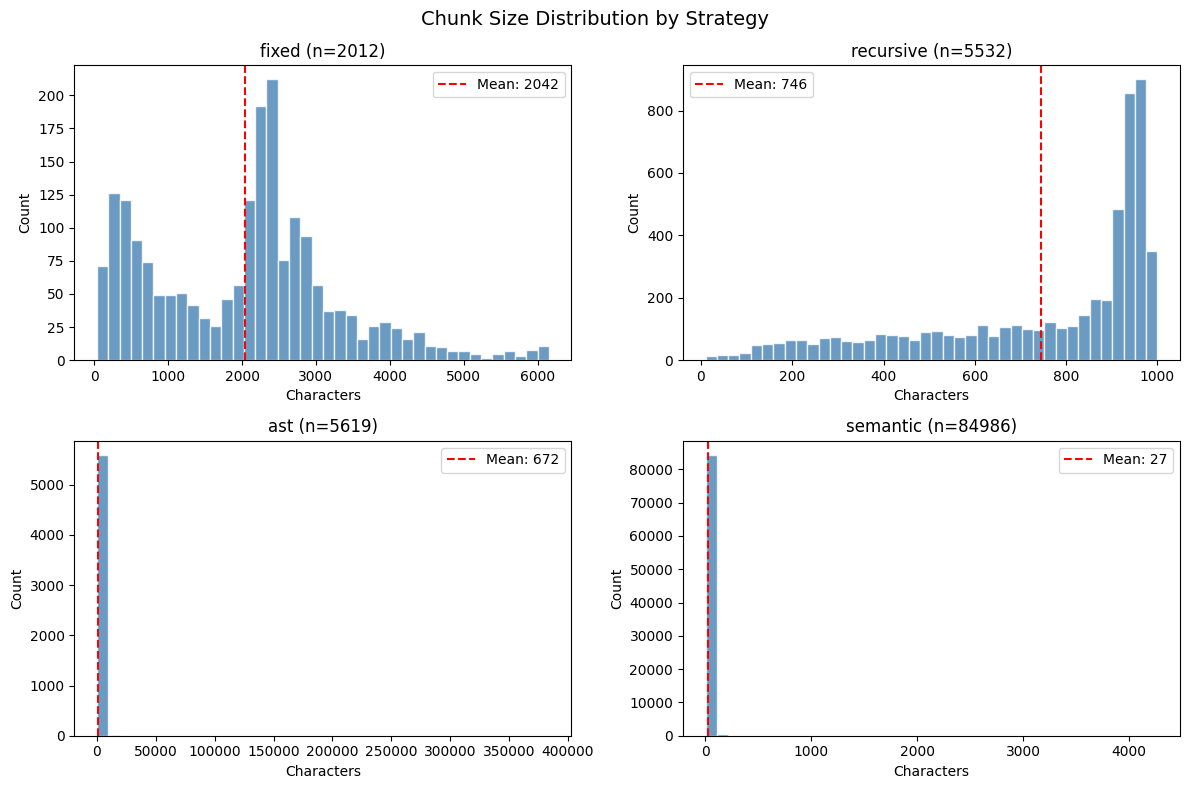

Saved to evaluation/results/chunk_size_distribution.png


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ensure output directory exists before saving
Path('../evaluation/results').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Chunk Size Distribution by Strategy', fontsize=14)

for ax, (name, chunks) in zip(axes.flat, strategies.items()):
    sizes = [len(c.page_content) for c in chunks]
    ax.hist(sizes, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name} (n={len(chunks)})')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.axvline(np.mean(sizes), color='red', linestyle='--', label=f'Mean: {np.mean(sizes):.0f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../evaluation/results/chunk_size_distribution.png', dpi=150)
plt.show()
print('Saved to evaluation/results/chunk_size_distribution.png')

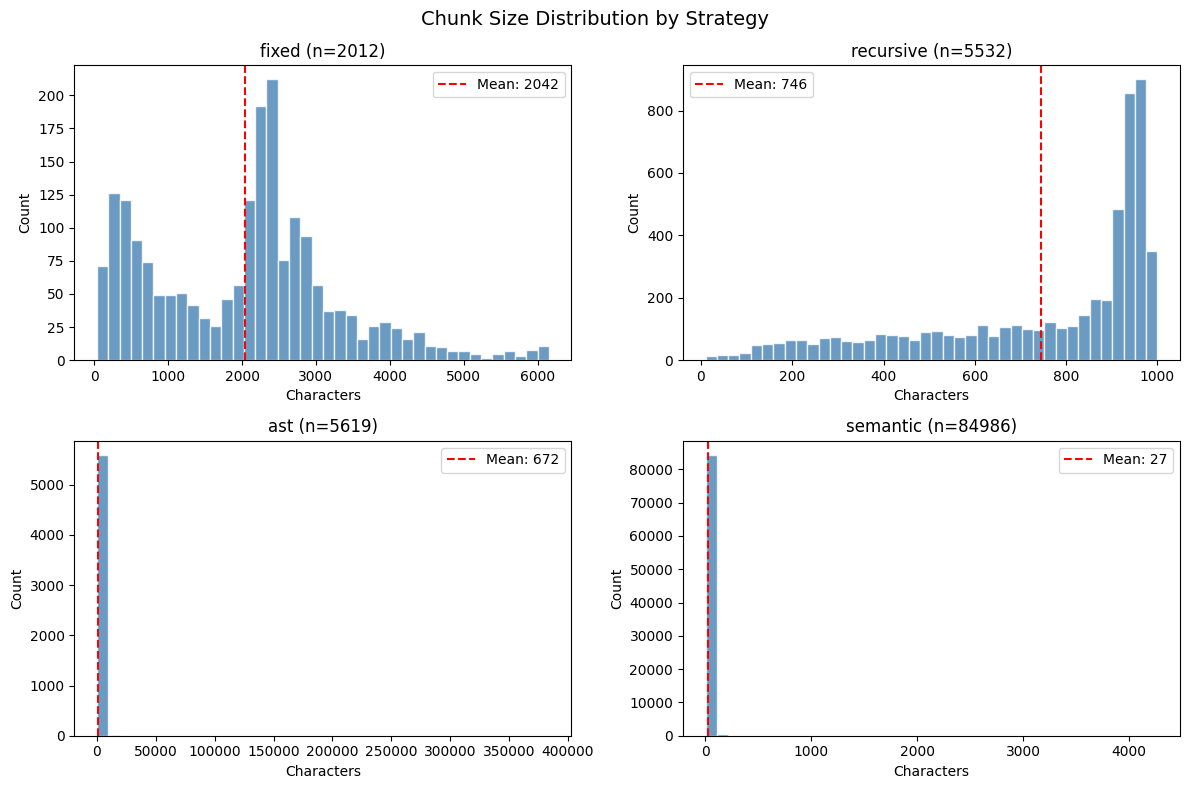

Saved to evaluation/results/chunk_size_distribution.png


In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ensure output directory exists before saving
Path('../evaluation/results').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Chunk Size Distribution by Strategy', fontsize=14)

for ax, (name, chunks) in zip(axes.flat, strategies.items()):
    sizes = [len(c.page_content) for c in chunks]
    ax.hist(sizes, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name} (n={len(chunks)})')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.axvline(np.mean(sizes), color='red', linestyle='--', label=f'Mean: {np.mean(sizes):.0f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../evaluation/results/chunk_size_distribution.png', dpi=150)
plt.show()
print('Saved to evaluation/results/chunk_size_distribution.png')

In [10]:
ast_chunks = strategies['ast']
func_chunks = [c for c in ast_chunks if c.metadata.get('node_type') == 'function']
print(f'Function chunks: {len(func_chunks)}')

if not func_chunks:
    print('No function chunks found — check that ast_chunker ran on Python files.')
else:
    sample = func_chunks[0]
    print('\nSample function chunk:')
    print(f'  File:     {sample.metadata["file_path"]}')
    print(f'  Function: {sample.metadata["node_name"]}')
    print(f'  Lines:    {sample.metadata.get("start_line")}-{sample.metadata.get("end_line")}')
    print('---')
    print(sample.page_content[:500])

Function chunks: 3273

Sample function chunk:
  File:     docs_src\app_testing\tutorial001_py310.py
  Function: test_read_main
  Lines:    15-18
---
def test_read_main():
    response = client.get("/")
    assert response.status_code == 200
    assert response.json() == {"msg": "Hello World"}

